<a href="https://colab.research.google.com/github/gonzalo-marrero/NGC5443-Photometric-Decomposition/blob/main/P1_extrag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install astropy

In [3]:
from astropy.io.ascii import read
import numpy as np
myfile = read('data/NGC5443_i.txt')
xx = myfile['SMA']
yy = myfile['INTENSITY']


In [4]:
magcal = -23.660299
escpl = 0.396 #arcseg/pix

In [5]:
# Paso la intensidad a magnitudes
mu = -2.5*np.log10(yy)-magcal+5*np.log10(escpl)
i=499.6
er_i=5.4
mu_i= -2.5*np.log10(i)-magcal+5*np.log10(escpl)
mu_er= (-2.5*er_i)/(np.log(10)*i)
mu_i
#mu_er

np.float64(14.902218855372315)

In [6]:
# Se define la funcion Sersic y exponencial

#Sersic
Ie = 369.942
n = 2.73839
bn = ((2*n)-0.327)
Re = 9.52574
print(bn)
Isersic = Ie*np.exp(-bn*((xx/Re)**(1/n)-1))
MuSersic = -2.5*np.log10(Isersic) -magcal+5*np.log10(escpl)

#Exponencial:
h = 57.2134
I0 = 499.584
Iexp = I0*np.exp(-xx/h)
Muexp = -2.5*np.log10(Iexp) -magcal+5*np.log10(escpl)

#Sersic + Exp:

Itot = Isersic + Iexp

# Pasamos a magnitudes:

Mutot = -2.5*np.log10(Itot)-magcal+5*np.log10(escpl)


5.14978


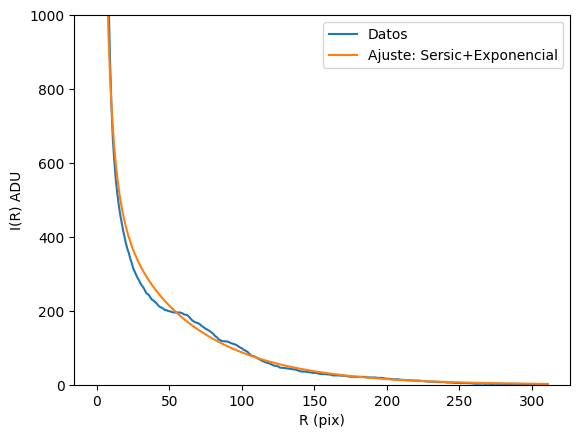

In [7]:
#Pintamos los datos para verificar si el ajuste lineal es el adecuado:
import matplotlib.pyplot as plt
plt.plot(xx,yy, label ="Datos")
plt.plot(xx,Itot, label = "Ajuste: Sersic+Exponencial")
plt.xlabel("R (pix)")
plt.ylabel("I(R) ADU")
plt.legend(loc = "upper right")
#plt.axis([min(xx),max(xx),max(yy2),min(yy2)])
#plt.xlim(0,300)
#plt.axvline(25, color ='b',linestyle = "--" )
plt.ylim(0,1000)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1303954876.py:32: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$(mag / $arc sec^2$)")


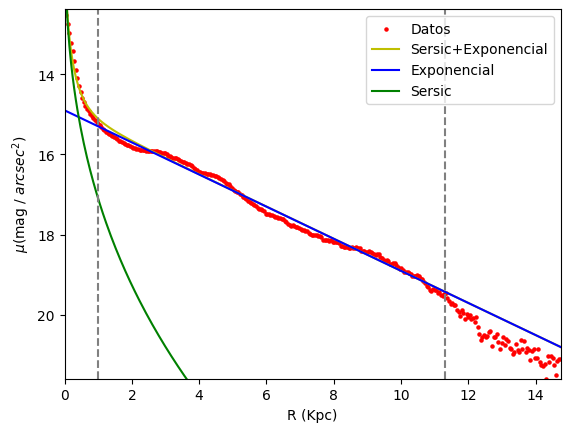

In [8]:
# Representación INTENSIDAD LOG vs. SMA.
xx = myfile['SMA']
yy = myfile['INTENSITY']
aa = myfile['INTENSITY_ERROR']
mu = -2.5*np.log10(yy)-magcal+5*np.log10(escpl)
aa_mu=-2.5*np.log10(aa)-magcal+5*np.log10(escpl)

#Pasemos de r(pix) a r(kpc)
H0=67.8 #km/s/Mpc
c=300000 #km/s
z=0.00599
r_arc=0.369*xx #radio en arc sec
r_rad=(np.pi/648000)*r_arc            # de arc sec a rad
d=(z*c)/(H0) *1000     #kpc
r_kpc=np.tan(r_rad)*d #radio en kpc

r_e_pix=57.2
r_e_kpc=np.tan(0.369*np.pi*r_e_pix/648000)*d
r_e_kpc
 #Empezaos a pintar
#xx2 = escpl*1000/xx #(kpc)
import matplotlib.pyplot as plt

plt.scatter(r_kpc,mu,label='Datos', color='r',s=5)
#plt.plot(xx2,MuSersic, label='Sersic', linestyle ='solid', color='b' )
#plt.plot(xx2,Muexp, label='Exponencial',linestyle ='solid', color='g')
plt.plot(r_kpc,Mutot, label='Sersic+Exponencial',linestyle ='solid', color='y')
plt.plot(r_kpc,Muexp, label='Exponencial',linestyle ='solid', color='b')
plt.plot(r_kpc,MuSersic, label='Sersic',linestyle ='solid', color='g')

plt.xlabel("R (Kpc)")
plt.ylabel("$\mu$(mag / $arc sec^2$)")
plt.legend(loc = "upper right")
#plt.axis([min(xx),max(xx),max(yy2),min(yy2)])
plt.xlim(0,25)
#plt.ylim(14,22)
plt.axis([min(r_kpc),max(r_kpc),max(mu),min(mu)])
plt.axvline(11.3, color ="grey", linestyle = "--")  #Termina el disco
plt.axvline(1, color ="grey", linestyle = "--")  #Termina el bulbo

plt.show()

# El radio efectivo: re, cuando se produce un cambio de pendiente al representar intensidad en logaritmo.


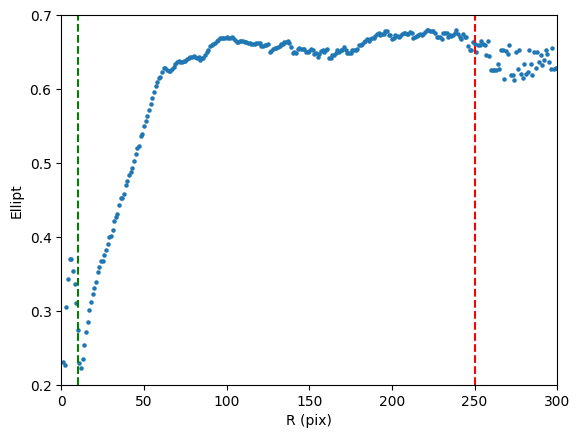

np.float64(2.7121621232988824)

In [15]:
# Representación ELIPTICIDAD vs. SMA.
xx = myfile['SMA']
zz = myfile['ELLIP']
import matplotlib.pyplot as plt
plt.scatter(xx,zz, s=5)
plt.xlabel("R (pix)")
plt.ylabel("Ellipt")
plt.xlim(0,300)
plt.ylim(0.2,0.7)
plt.axvline(250, color ="r", linestyle = "--")
plt.axvline(10, color ="g", linestyle = "--")
plt.show()
r_e_kpc
# El radio del bulbo: rb, cuando se produce una tendencia constante al representar elipticidad contra radio.

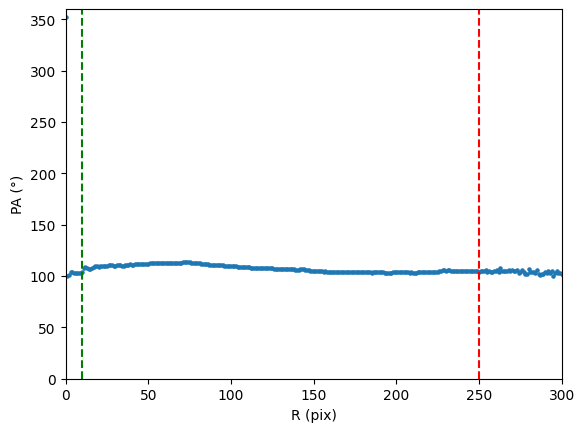

In [16]:
import matplotlib.pyplot as plt

xx = myfile['SMA']
ww = myfile['PA']
ww_mod = (ww + 180) % 360  # ajusta al rango 0-360°

plt.scatter(xx, ww_mod, s=5)
plt.xlabel("R (pix)")
plt.ylabel("PA (°)")
plt.xlim(0, 300)
plt.ylim(0, 360)           # opcional, para ver toda la rotación
plt.axvline(250, color="r", linestyle="--")
plt.axvline(10, color="g", linestyle="--")
plt.show()


In [17]:
"""# Representación PA vs. SMA.
xx = myfile['SMA']
ww = myfile['PA']
ww2 = ww+180
import matplotlib.pyplot as plt
plt.scatter(xx,ww2, s=5)
plt.xlabel("R (pix)")
plt.ylabel("PA")
plt.xlim(0,300)
#plt.ylim(0,5)
plt.axvline(250, color ="r", linestyle = "--")
plt.axvline(10, color ="g", linestyle = "--")
plt.show()"""


'# Representación PA vs. SMA. \nxx = myfile[\'SMA\']\nww = myfile[\'PA\']\nww2 = ww+180\nimport matplotlib.pyplot as plt\nplt.scatter(xx,ww2, s=5)\nplt.xlabel("R (pix)")\nplt.ylabel("PA")\nplt.xlim(0,300)\n#plt.ylim(0,5)\nplt.axvline(250, color ="r", linestyle = "--")\nplt.axvline(10, color ="g", linestyle = "--")\nplt.show()'

In [12]:
#Sersic
Ie = 369.942
n = 2.73839
bn = ((2*n)-0.327)
Re = 9.52574

#Exponencial:
h = 57.2134
I0 = 499.584

import sympy as sp
#Calculo de la luminosidad el disco y del bulbo B/T y D/T
L_disco=2*np.pi*I0*h**2
#Bulbo
bn
#calculo de la funcion gamma
'''
R=20
from math import inf
x=bn*((R/Re)**(1/n))
t= sp.Symbol('t')
y=t**(2*n-1)*np.exp(-t)
a=0
b=inf
sp.integrate(y,(t,a,b))
'''

# mu_rbulbo=mu[20]
# radio galaxia:r_kpc[238]


"\nR=20\nfrom math import inf\nx=bn*((R/Re)**(1/n))\nt= sp.Symbol('t')\ny=t**(2*n-1)*np.exp(-t)\na=0\nb=inf\nsp.integrate(y,(t,a,b))\n"

In [13]:
from scipy.special import gamma
gamma(5.476)


np.float64(50.36040413863749)